                                        reviews.text  reviews.rating
0  I thought it would be as big as small paper bu...               3
1  This kindle is light and easy to use especiall...               5
2  Didnt know how much i'd use a kindle so went f...               4
3  I am 100 happy with my purchase. I caught it o...               5
4  Solid entry level Kindle. Great for kids. Gift...               5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.00      0.00      0.00        39
           2       0.94      1.00      0.97       937

    accuracy                           0.94      1000
   macro avg       0.31      0.33      0.32      1000
weighted avg       0.88      0.94      0.91      1000


Confusion Matrix:
 [[  0   0  24]
 [  0   0  39]
 [  0   0 937]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


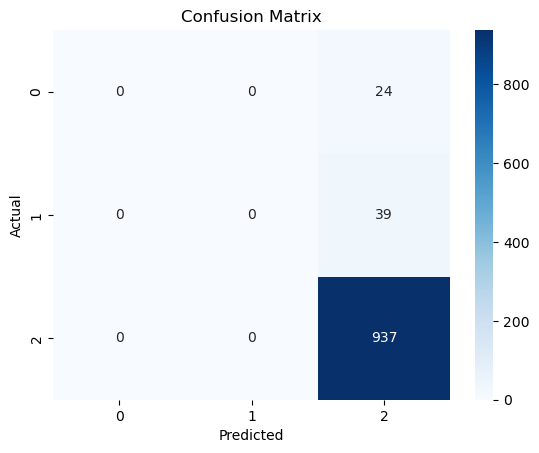

'\nimport streamlit as st\nimport pandas as pd\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.naive_bayes import MultinomialNB\n\nst.title("Sentiment Analysis Dashboard")\nfile = st.file_uploader("Upload CSV File", type="csv")\n\nif file:\n    df = pd.read_csv(file)\n    def preprocess_text(text):\n        text = re.sub(r\'[^a-zA-Z]\', \' \', str(text))\n        text = text.lower().strip()\n        tokens = text.split()\n        return \' \'.join(tokens)\n\n    df[\'cleaned_text\'] = df[\'reviews.text\'].astype(str).apply(preprocess_text)\n    vectorizer = TfidfVectorizer(max_features=5000)\n    X = vectorizer.fit_transform(df[\'cleaned_text\']).toarray()\n    model = MultinomialNB().fit(X, [\'positive\'] * len(X))  # dummy fit\n    df[\'predicted_sentiment\'] = model.predict(X)\n    st.write(df[[\'reviews.text\', \'predicted_sentiment\']])\n    st.bar_chart(df[\'predicted_sentiment\'].value_counts())\n'

In [4]:
# Sentiment Analysis for Product Reviews

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Step 2: Load Dataset (Use appropriate CSV file)
df = pd.read_csv('Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
print(df[['reviews.text', 'reviews.rating']].head())

# Step 3: Data Preprocessing
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    text = text.lower().strip()
    tokens = text.split()
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['reviews.text'].apply(preprocess_text)

# Step 4: Sentiment Labeling based on Rating
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['reviews.rating'].apply(get_sentiment)

# Step 5: Convert Text to Features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text']).toarray()
y = LabelEncoder().fit_transform(df['sentiment'])

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 8: Evaluate Model
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 9: Visualize Misclassifications
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




/var/folders/3w/kj_7yw213hqgk__h5h1dr4hw0000gn/T/ipykernel_6487/3110733071.py:25: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


                                        reviews.text  reviews.rating
0  This product so far has not disappointed. My c...             5.0
1  great for beginner or experienced person. Boug...             5.0
2  Inexpensive tablet for him to use and learn on...             5.0
3  I've had my Fire HD 8 two weeks now and I love...             4.0
4  I bought this for my grand daughter when she c...             5.0

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.74      0.39       509
           1       0.17      0.61      0.27       580
           2       0.99      0.80      0.88     12510

    accuracy                           0.79     13599
   macro avg       0.47      0.72      0.51     13599
weighted avg       0.92      0.79      0.84     13599


Confusion Matrix:
 [[ 378  100   31]
 [ 116  352  112]
 [ 947 1568 9995]]


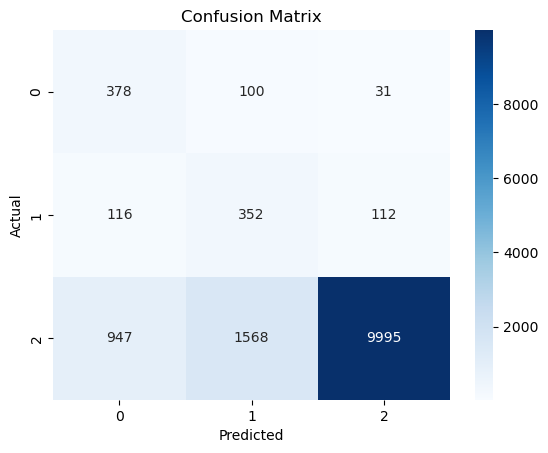

'\nimport streamlit as st\nimport pandas as pd\nimport re\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.naive_bayes import MultinomialNB\n\nst.title("Sentiment Analysis Dashboard")\nfile = st.file_uploader("Upload CSV File", type="csv")\n\nif file:\n    df = pd.read_csv(file)\n    def preprocess_text(text):\n        text = re.sub(r\'[^a-zA-Z]\', \' \', str(text))\n        text = text.lower().strip()\n        tokens = text.split()\n        return \' \'.join(tokens)\n\n    df[\'cleaned_text\'] = df[\'reviews.text\'].astype(str).apply(preprocess_text)\n    vectorizer = TfidfVectorizer(max_features=5000)\n    X = vectorizer.fit_transform(df[\'cleaned_text\']).toarray()\n    model = MultinomialNB().fit(X, [\'positive\'] * len(X))  # dummy fit\n    df[\'predicted_sentiment\'] = model.predict(X)\n    st.write(df[[\'reviews.text\', \'predicted_sentiment\']])\n    st.bar_chart(df[\'predicted_sentiment\'].value_counts())\n'

In [5]:
# Sentiment Analysis for Product Reviews

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Step 2: Load and Combine Datasets
files = [
    '1429_1.csv',
    'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
    'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv'
]

df_list = []
for file in files:
    temp_df = pd.read_csv(file)
    if 'reviews.text' in temp_df.columns and 'reviews.rating' in temp_df.columns:
        df_list.append(temp_df[['reviews.text', 'reviews.rating']])

# Combine all datasets into one
combined_df = pd.concat(df_list, ignore_index=True)
print(combined_df.head())

# Step 3: Data Preprocessing
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    text = text.lower().strip()
    tokens = text.split()
    return ' '.join(tokens)

# Apply preprocessing
combined_df['cleaned_text'] = combined_df['reviews.text'].apply(preprocess_text)

# Step 4: Sentiment Labeling based on Rating
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

combined_df['sentiment'] = combined_df['reviews.rating'].apply(get_sentiment)

# Step 5: Convert Text to Features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(combined_df['cleaned_text']).toarray()
y = LabelEncoder().fit_transform(combined_df['sentiment'])

# Step 6: Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 7: Handle Class Imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

# Step 8: Train Model
model = MultinomialNB()
model.fit(X_train_resampled, y_train_resampled)

# Step 9: Evaluate Model
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 10: Visualize Misclassifications
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [7]:
import pickle

# Save trained model
with open("sentiment_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as vec_file:
    pickle.dump(vectorizer, vec_file)


In [8]:
import streamlit as st
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle

# Preprocessing function
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    text = text.lower().strip()
    tokens = text.split()
    return ' '.join(tokens)

# Load the trained model and vectorizer
@st.cache_resource
def load_model():
    model = pickle.load(open('sentiment_model.pkl', 'rb'))
    vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
    return model, vectorizer

model, vectorizer = load_model()

# Streamlit UI
st.title("📦 Amazon Product Review Sentiment Analysis")

file = st.file_uploader("📁 Upload CSV File with 'reviews.text' column", type="csv")

if file:
    df = pd.read_csv(file)
    
    if 'reviews.text' not in df.columns:
        st.error("Uploaded file must have a 'reviews.text' column.")
    else:
        df['cleaned_text'] = df['reviews.text'].astype(str).apply(preprocess_text)
        X = vectorizer.transform(df['cleaned_text']).toarray()
        df['predicted_sentiment'] = model.predict(X)
        label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
        df['predicted_sentiment'] = df['predicted_sentiment'].map(label_map)

        st.success("✅ Sentiment prediction complete!")
        st.write(df[['reviews.text', 'predicted_sentiment']])
        st.bar_chart(df['predicted_sentiment'].value_counts())


2025-07-17 09:18:30.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-17 09:18:30.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar